In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import read_log

In [2]:
path = '../backtests/submission.log'
with open(path, 'r') as f:
    data = json.load(f)

In [3]:
data.keys()

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])

In [4]:
activities = pd.read_csv(io.StringIO(data['activitiesLog']), sep=';')
trades = pd.DataFrame(data['tradeHistory'])

In [29]:
pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

In [31]:
pepper['profit_and_loss'].iloc[999] + osmium['profit_and_loss'].iloc[999]

np.float64(6076.0)

In [60]:
pepper_pnl = pepper[pepper['profit_and_loss'] >= -1000][pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
osmium_pnl = osmium[osmium['profit_and_loss'] >= -1000][osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]

C:\Users\aeali\AppData\Local\Temp\ipykernel_10192\2012199334.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pepper_pnl = pepper[pepper['profit_and_loss'] >= -1000][pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
C:\Users\aeali\AppData\Local\Temp\ipykernel_10192\2012199334.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  osmium_pnl = osmium[osmium['profit_and_loss'] >= -1000][osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]


In [61]:
pepper_trades = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].set_index('timestamp').loc[:99900]
osmium_trades = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].set_index('timestamp').loc[:99900]

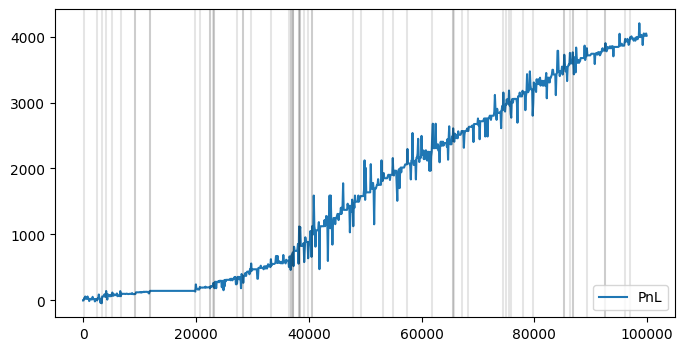

In [71]:
plt.figure(figsize=(8, 4))
plt.plot(pepper_pnl, label='PnL')
for row in pepper_trades.iterrows():
    plt.axvline(row[0], c='k', alpha=0.1)
plt.legend()
plt.show()

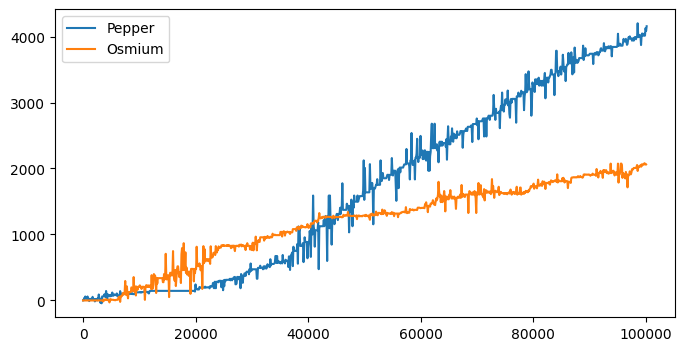

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(pepper_pnl, label='Pepper')
plt.plot(osmium_pnl, label='Osmium')
plt.legend()
plt.show()